# Tiền xử lý Dữ liệu Giao thông & Xây dựng Historical Baseline

1. **time_slot (96 khung)**: Thay vì gom theo 24 giờ, hệ thống gom theo khung 15 phút để đồng bộ với T15, T30, T45.
2. **day_type (3 loại)**: Tránh loãng dữ liệu bằng cách gom ngày (1: T2-T5, 2: T6, 3: T7-CN).
3. **Linear Interpolation**: Nội suy tuyến tính để tự lấp đầy các khung 15 phút bị thiếu xe buýt.

## 1. Import Thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os

# Cấu hình plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## 2. Load Dữ liệu Parquet & Làm sạch

In [2]:
parquet_file = r'../data/traffic_2026-06.parquet'
df = pd.read_parquet(parquet_file)
original_len = len(df)

# Lọc Outliers
df = df[(df['instant_speed_kmh'] >= 0) & (df['instant_speed_kmh'] <= 60)]

print(f"Số lượng bản ghi gốc: {original_len:,}")
print(f"Đã loại bỏ {original_len - len(df):,} bản ghi rác.")
print(f"Số bản ghi hợp lệ: {len(df):,}")

Số lượng bản ghi gốc: 1,974,355
Đã loại bỏ 1,576 bản ghi rác.
Số bản ghi hợp lệ: 1,972,779


## 3. Tạo Feature `time_slot` và `day_type`

In [3]:
# 1. Chuẩn hóa Múi giờ về GMT+7
if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC').dt.tz_convert('Asia/Ho_Chi_Minh')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Ho_Chi_Minh')

# 2. Xây dựng day_type (1: T2-T5, 2: T6, 3: Cuối tuần)
df['day_of_week'] = df['timestamp'].dt.dayofweek
def get_day_type(d):
    if d in [0, 1, 2, 3]: return 1
    if d == 4: return 2
    return 3
df['day_type'] = df['day_of_week'].apply(get_day_type)

# 3. Xây dựng time_slot (96 khung/ngày, mỗi khung 15 phút)
df['time_slot'] = df['timestamp'].dt.hour * 4 + df['timestamp'].dt.minute // 15

display(df[['timestamp', 'day_type', 'time_slot', 'instant_speed_kmh']].head())

,timestamp,day_type,time_slot,instant_speed_kmh
0,2026-06-11 12:46:35.885240+07:00,1,51,2
1,2026-06-11 12:46:36.028756+07:00,1,51,0
2,2026-06-11 12:46:36.028891+07:00,1,51,0
3,2026-06-11 12:46:36.300157+07:00,1,51,27
4,2026-06-11 12:46:36.623797+07:00,1,51,0


## 4. Trực quan hóa dữ liệu (Visualization)
Biểu đồ thể hiện tốc độ qua 96 khung giờ. Từ ô 28 (7h00) đến ô 36 (9h00) tốc độ thường chạm đáy.

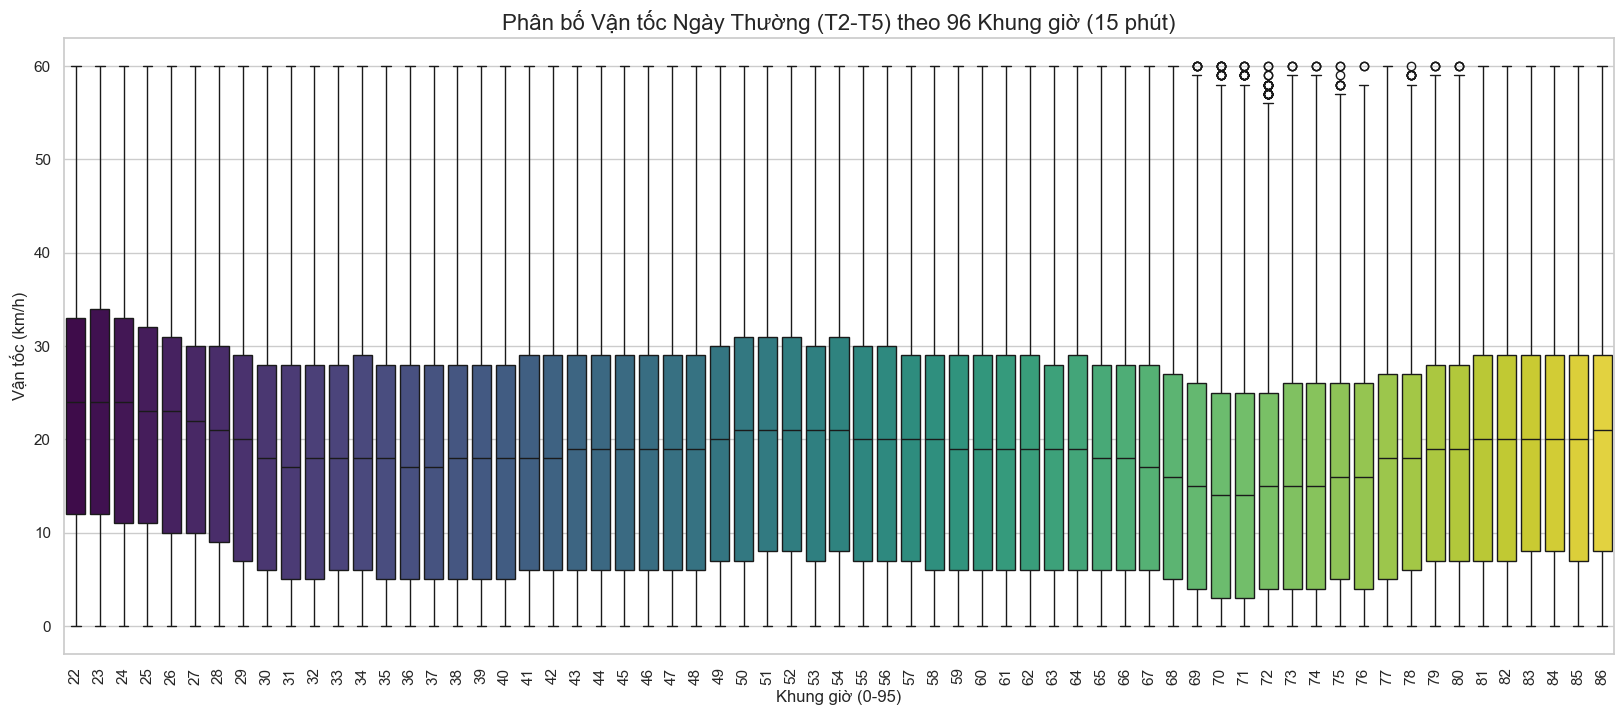

In [6]:
plt.figure(figsize=(20, 8))
# Vẽ riêng cho ngày thường (day_type = 1) để nhìn rõ giờ cao điểm
sns.boxplot(x='time_slot', y='instant_speed_kmh', data=df[df['day_type'] == 1], hue='time_slot', palette='viridis', legend=False)
plt.title('Phân bố Vận tốc Ngày Thường (T2-T5) theo 96 Khung giờ (15 phút)', fontsize=16)
plt.xlabel('Khung giờ (0-95)', fontsize=12)
plt.ylabel('Vận tốc (km/h)', fontsize=12)
plt.xticks(rotation=90)
plt.show()

## 5. Xây dựng Baseline & Nội suy tuyến tính (Linear Interpolation)

In [5]:
# 1. Gom nhóm cơ bản
grouped = df.groupby(['to_current_stop_id', 'to_next_stop_id', 'day_type', 'time_slot'])['instant_speed_kmh'].mean().reset_index()

# 2. Trải phẳng (Pivot) để lộ ra các khung giờ bị trống (Data Sparsity)
pivot_df = grouped.pivot_table(index=['to_current_stop_id', 'to_next_stop_id', 'day_type'], 
                               columns='time_slot', 
                               values='instant_speed_kmh')

# 3. Nội suy Tuyến tính (Linear Interpolate)
# limit=2: Chỉ lấp chỗ trống nếu mất tối đa 30 phút. Nếu mất lâu hơn (xe buýt nghỉ đêm), cứ để NaN.
pivot_df = pivot_df.interpolate(method='linear', axis=1, limit=2, limit_direction='both')

# 4. Nén lại (Stack)
baseline = pivot_df.stack().reset_index()
baseline.rename(columns={0: 'instant_speed_kmh'}, inplace=True)

# 5. Chuyển thành Flat Dictionary O(1)
baseline_dict = {}
for row in baseline.itertuples(index=False):
    baseline_dict[(row.to_current_stop_id, row.to_next_stop_id, row.day_type, row.time_slot)] = round(row.instant_speed_kmh, 2)

output_file = r'../data/historical_baseline.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(baseline_dict, f)

print(f"Hoàn tất! Đã lưu {len(baseline_dict):,} bản ghi vào {output_file}.")
print(f"Dung lượng file: {os.path.getsize(output_file) / 1024 / 1024:.2f} MB")

Hoàn tất! Đã lưu 728,720 bản ghi vào ../data/historical_baseline.pkl.
Dung lượng file: 15.18 MB
